 **Install & Import Libraries**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

**Load the Dataset**

In [ ]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Basic Inspection**

In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Summary Statistics**

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Check for Missing Values (Disguised as Zeros)**

In [ ]:
# Pregnancies CAN legitimately be 0, so it's excluded from this list.
# These 5 columns cannot physiologically be 0 — a 0 here means the value is missing.
cols_with_disguised_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_disguised_zeros:
    print(col, "zero count:", (df[col] == 0).sum())

Glucose zero count: 5
BloodPressure zero count: 35
SkinThickness zero count: 227
Insulin zero count: 374
BMI zero count: 11


**Replace Disguised Zeros with NaN, Then Impute with Median**

In [ ]:
for col in cols_with_disguised_zeros:
    df[col] = df[col].replace(0, np.nan)

# Median is used instead of mean because these features (especially Insulin) have outliers,
# and median is more robust to skewed distributions
for col in cols_with_disguised_zeros:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**Check and Remove Duplicates**

In [ ]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows: 0
Duplicate rows after cleaning: 0


**Check Class Balance**

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


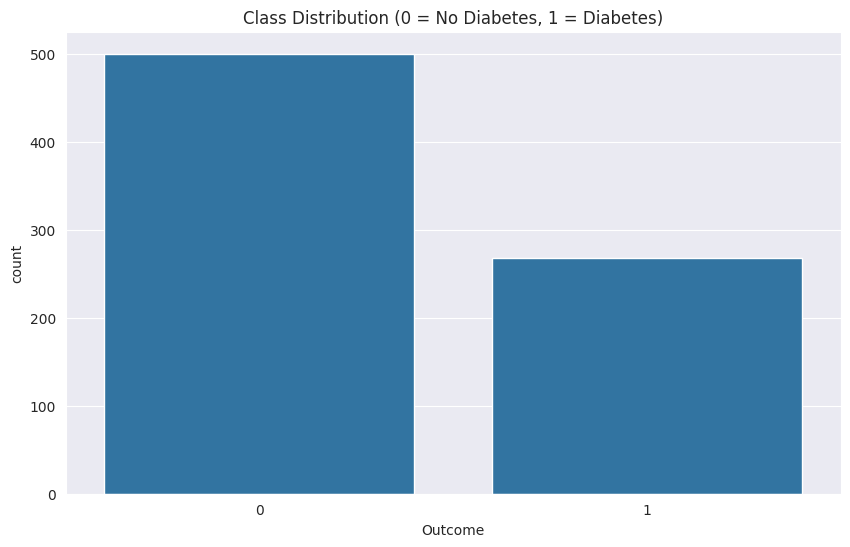

In [ ]:
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True) * 100)  # shows the ~65/35 split as percentages

sns.countplot(x='Outcome', data=df)
plt.title('Class Distribution (0 = No Diabetes, 1 = Diabetes)')
plt.show()

**EDA: Feature Distributions**

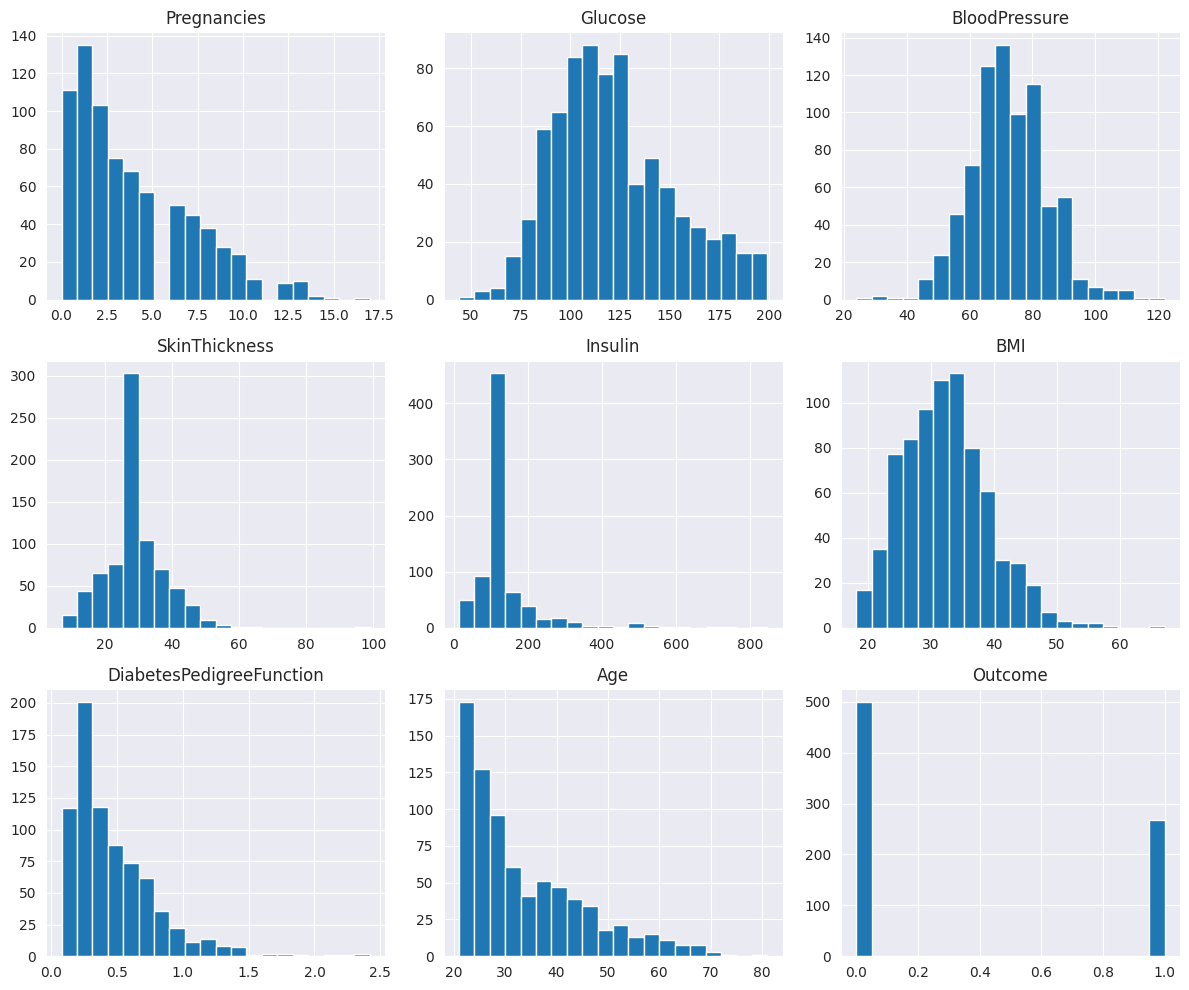

In [ ]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

**Correlation Matrix**

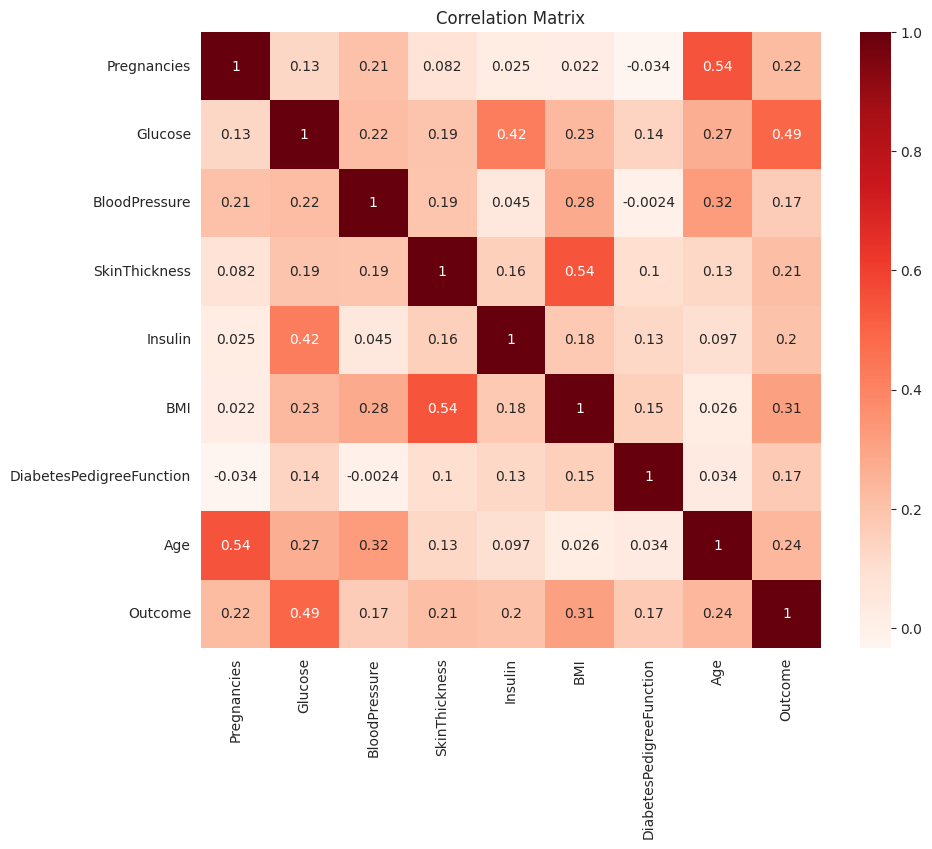

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='Reds')
plt.title('Correlation Matrix')
plt.show()
# Expect Glucose, BMI, and Age to show the strongest correlation with Outcome

**Outcome vs Key Features (Glucose, BMI, Age)**

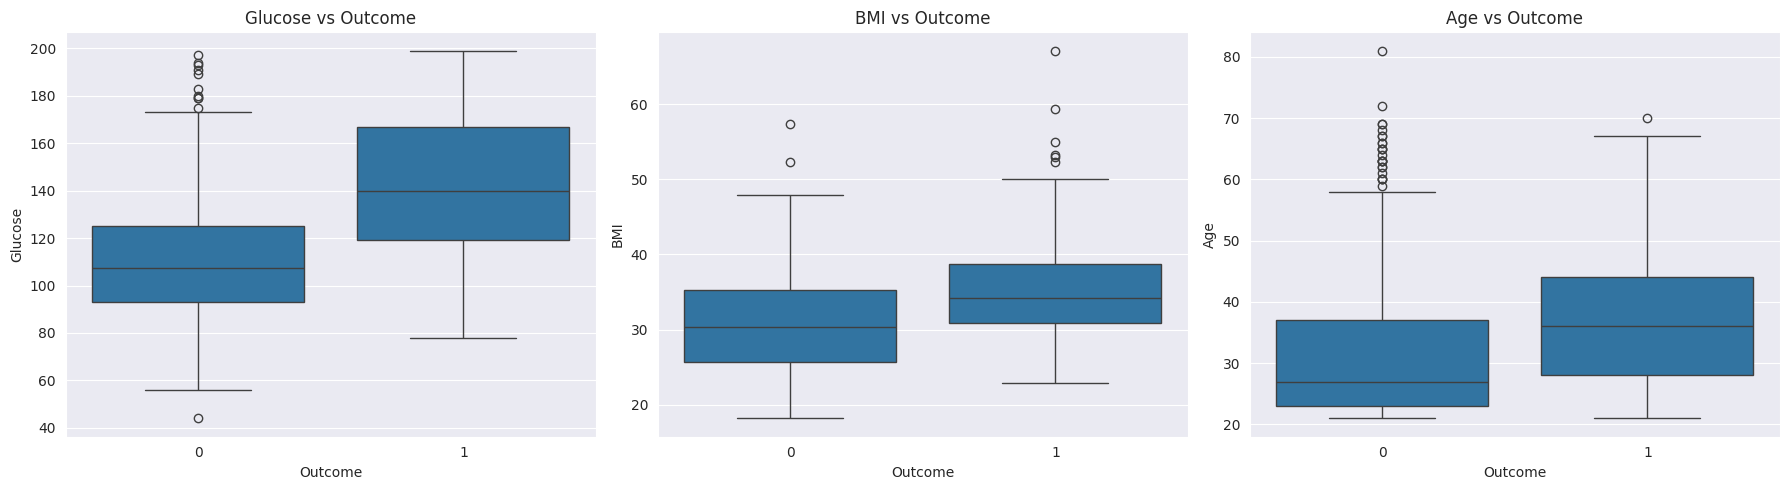

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0])
axes[0].set_title('Glucose vs Outcome')

sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[1])
axes[1].set_title('BMI vs Outcome')

sns.boxplot(x='Outcome', y='Age', data=df, ax=axes[2])
axes[2].set_title('Age vs Outcome')

plt.tight_layout()
plt.show()

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# stratify=y keeps the 65/35 class ratio consistent in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (614, 8)
Test set size: (154, 8)


**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Needed for KNN, SVM, Logistic Regression (distance/gradient-based)
# NOT needed for Decision Tree or Random Forest (tree-based, scale-invariant)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_probs)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression ROC-AUC:", lr_auc)
print(confusion_matrix(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.7077922077922078
Logistic Regression ROC-AUC: 0.812962962962963
[[82 18]
 [27 27]]
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_probs = dt_model.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, dt_preds)
dt_auc = roc_auc_score(y_test, dt_probs)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree ROC-AUC:", dt_auc)
print(confusion_matrix(y_test, dt_preds))
print(classification_report(y_test, dt_preds))

Decision Tree Accuracy: 0.6818181818181818
Decision Tree ROC-AUC: 0.6357407407407407
[[79 21]
 [28 26]]
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probs)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest ROC-AUC:", rf_auc)
print(confusion_matrix(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.7792207792207793
Random Forest ROC-AUC: 0.8191666666666666
[[88 12]
 [22 32]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



**K-Nearest Neighbors (KNN)**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
knn_probs = knn_model.predict_proba(X_test_scaled)[:, 1]

knn_accuracy = accuracy_score(y_test, knn_preds)
knn_auc = roc_auc_score(y_test, knn_probs)

print("KNN Accuracy:", knn_accuracy)
print("KNN ROC-AUC:", knn_auc)
print(confusion_matrix(y_test, knn_preds))
print(classification_report(y_test, knn_preds))

KNN Accuracy: 0.7532467532467533
KNN ROC-AUC: 0.7886111111111112
[[83 17]
 [21 33]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



** Support Vector Machine (SVM)**

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)  # probability=True needed to get scores for ROC-AUC
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

svm_accuracy = accuracy_score(y_test, svm_preds)
svm_auc = roc_auc_score(y_test, svm_probs)

print("SVM Accuracy:", svm_accuracy)
print("SVM ROC-AUC:", svm_auc)
print(confusion_matrix(y_test, svm_preds))
print(classification_report(y_test, svm_preds))

SVM Accuracy: 0.7402597402597403
SVM ROC-AUC: 0.7963888888888889
[[84 16]
 [24 30]]
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



**Hyperparameter Tuning (Random Forest & KNN)**

In [ ]:
from sklearn.model_selection import GridSearchCV

# --- Tune Random Forest ---
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
rf_tuned_model = rf_grid.best_estimator_
rf_tuned_preds = rf_tuned_model.predict(X_test)
rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_preds)
print("Tuned Random Forest Test Accuracy:", rf_tuned_accuracy)

# --- Tune KNN ---
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train)

print("Best KNN Parameters:", knn_grid.best_params_)
knn_tuned_model = knn_grid.best_estimator_
knn_tuned_preds = knn_tuned_model.predict(X_test_scaled)
knn_tuned_accuracy = accuracy_score(y_test, knn_tuned_preds)
print("Tuned KNN Test Accuracy:", knn_tuned_accuracy)

Best Random Forest Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest Test Accuracy: 0.7402597402597403
Best KNN Parameters: {'n_neighbors': 15, 'weights': 'distance'}
Tuned KNN Test Accuracy: 0.7337662337662337


**Compare All Models (Baseline + Tuned)**

                   Model  Accuracy   ROC-AUC
2          Random Forest  0.779221  0.819167
3                    KNN  0.753247  0.788611
4                    SVM  0.740260  0.796389
5  Random Forest (Tuned)  0.740260       NaN
6            KNN (Tuned)  0.733766       NaN
0    Logistic Regression  0.707792  0.812963
1          Decision Tree  0.681818  0.635741


/tmp/ipykernel_608/1798776333.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results, palette='viridis')


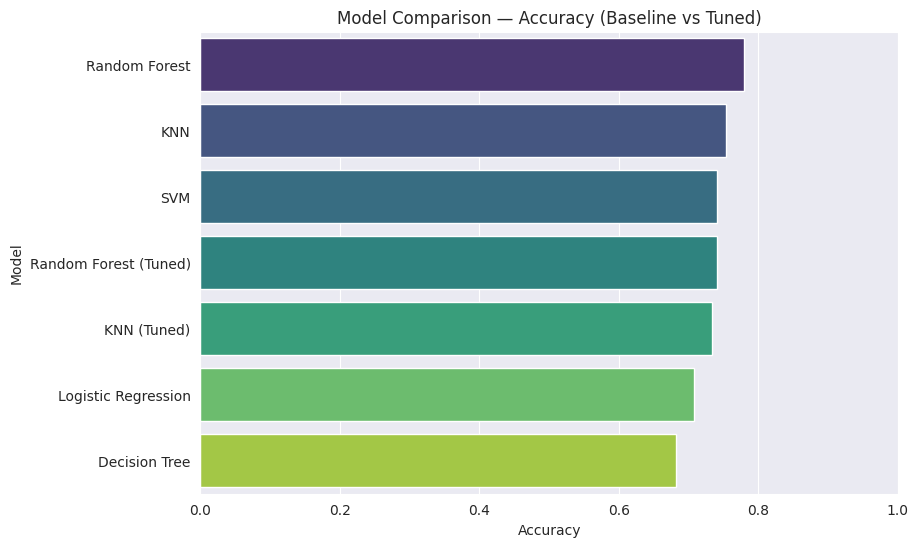

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM',
              'Random Forest (Tuned)', 'KNN (Tuned)'],
    'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy, knn_accuracy, svm_accuracy,
                 rf_tuned_accuracy, knn_tuned_accuracy],
    'ROC-AUC': [lr_auc, dt_auc, rf_auc, knn_auc, svm_auc, np.nan, np.nan]
})

results = results.sort_values(by='Accuracy', ascending=False)
print(results)

plt.figure(figsize=(9, 6))
sns.barplot(x='Accuracy', y='Model', data=results, palette='viridis')
plt.title('Model Comparison — Accuracy (Baseline vs Tuned)')
plt.xlim(0, 1)
plt.show()

**Check for Overfitting (Train vs Test Accuracy)**

In [ ]:
models = {
    'Logistic Regression': (lr_model, X_train_scaled, X_test_scaled),
    'Decision Tree': (dt_model, X_train, X_test),
    'Random Forest': (rf_model, X_train, X_test),
    'KNN': (knn_model, X_train_scaled, X_test_scaled),
    'SVM': (svm_model, X_train_scaled, X_test_scaled)
}

for name, (model, xtr, xte) in models.items():
    train_acc = accuracy_score(y_train, model.predict(xtr))
    test_acc = accuracy_score(y_test, model.predict(xte))
    print(f"{name}: Train Accuracy = {train_acc:.3f}, Test Accuracy = {test_acc:.3f}")

Logistic Regression: Train Accuracy = 0.796, Test Accuracy = 0.708
Decision Tree: Train Accuracy = 1.000, Test Accuracy = 0.682
Random Forest: Train Accuracy = 1.000, Test Accuracy = 0.779
KNN: Train Accuracy = 0.831, Test Accuracy = 0.753
SVM: Train Accuracy = 0.840, Test Accuracy = 0.740
